In [1]:
import warnings
warnings.filterwarnings('ignore')

from functions import *
import time
import random

from scipy.stats import linregress, ks_2samp, mannwhitneyu, anderson_ksamp, pearsonr
from sklearn.linear_model import LinearRegression
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import seaborn as sns

palette = 'viridis'
font = {'color':  'black', 'weight': 'normal','size': 14}
font_cb = { 'color':  'black', 'weight': 'normal','size': 12}
labelsize=12

data = pd.read_csv('Dados\data.csv', index_col='Cluster')
df = pd.read_csv(r'Dados\results.csv', index_col='Cluster')
df.sort_index(inplace=True)
data.sort_index(inplace=True)
benchmark_subsample = df[(df.Av<0.5) & (df.dist<1.5)].copy()

<>:25: SyntaxWarning: invalid escape sequence '\d'
<>:25: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Ruan\AppData\Local\Temp\ipykernel_2332\525287329.py:25: SyntaxWarning: invalid escape sequence '\d'
  data = pd.read_csv('Dados\data.csv', index_col='Cluster')


In [20]:
def find_k_nearest_cluster(df, idx, k=5, av_lim=.5, dist_lim=1.5):
    """
    Função que encontra os k aglomerados mais próximos em idade, metalicidade, massa total e quantidade de membros, dentro de uma subamostra de
    aglomerados com distâncias e avermelhamentos baixos.
    
    A função recebe os seguintes parâmetros:
    df -> dataframe com as propriedades de todos os aglomerados
    idx -> indice do aglomerado que queremos encontrar seus semelhantes
    k -> número dos aglomerados mais próximos que a função vai retornar
    av_lim -> avermelhamento máximo considerado para a subamostra de referencia
    dist_lim -> distância máxima considerada para a subamostra de referência

    E retorna os indices e as distâncias dos k-aglomerados mais próximos
    """
    
    params = ['age', 'FeH', 'mass_total', 'n_members']
    mask_ref = (df.Av < av_lim) & (df.dist < dist_lim) & (df.index != idx)
    ref_sample = df[mask_ref]   
    dists = []

    for cluster in ref_sample.index:
        d = distance.euclidean(ref_sample.loc[cluster, params],
                               df.loc[idx, params])
        dists.append((d, cluster))

    dists.sort(key=lambda x: x[0])
    return dists[:k] 

def corr_fb(df, idx, q=0, k=5, av_lim=.5, dist_lim=1.5,):
    """
    Retorna o valor corrigido de fb. O valor de fb corrigido considera a média ponderada dos k aglomerados mais próximos dentro da subamostra 
    de referência. Os pesos são inversamente proporcionais as distâncias (no espaço dos parâmetros) entre o aglomerado analisado e seus k-aglomerados
    semelhantes, dando maior peso aos que possuem uma distância menor.
    """
    nearest = find_k_nearest_cluster(df, idx, k, av_lim, dist_lim,) #Encontra os k semelhantes 

    #O parâmetro q define se a correção vai ser feita na coluna bin_frac, que considera a fração de binárias total do aglomerado ou em uma coluna com
    #bin_frac_q, que considera apenas binárias com razões de massa >= q
    if q==0:
        col = 'bin_frac'
    else:
        col = 'bin_frac_05'
    fb_k = df.loc[idx, col]

    dists = np.array([d for d, _ in nearest])
    pesos = 1/dists
    pesos = pesos/pesos.sum() #normaliza os pesos
    fb_ref = np.array([df.loc[c, col] for _, c in nearest]) #obtem os valores de fb dos k-aglomerados semelhantes
    return (fb_ref*pesos).sum()
    
for cluster in df.index:
    df.loc[cluster, 'bin_frac_corr'] = corr_fb(df, cluster,)
    df.loc[cluster, 'bin_frac_05_corr'] = corr_fb(df, cluster,q=0.5)

In [21]:
def calcula_sigma_sys(data, N, n_bootstrap=1000, random_state=None):
    
    rng = np.random.default_rng(random_state)

    clusters = data["Cluster"].unique()
    sigma_sys = []
    fb_corrigido = []
    for j, cluster in enumerate(clusters):
        df_cluster = data[data["Cluster"] == cluster].copy()
        idx_bin = df_cluster[df_cluster["flag_binary"] == 1].index 
        idx_single = df_cluster[df_cluster["flag_binary"] == 0].index
        bootstrap_fb = []
        for _ in range(n_bootstrap):
            aux = df_cluster.copy(deep=True)          

            if N[j] > 0:
                N_boots = rng.integers(0, N[j])
                if N_boots>len(idx_bin):
                    N_boots=len(idx_bin)
                idx = rng.choice(idx_bin, size=np.abs(N_boots), replace=False)
                aux.loc[idx, "flag_binary"] = 0
            else:
                N_boots = rng.integers(N[j], 0)
                if np.abs(N_boots)>len(idx_single):
                    N_boots=len(idx_single)
                idx = rng.choice(idx_single, size= np.abs(N_boots), replace=False)
                aux.loc[idx, "flag_binary"] = 1

            fb = aux["flag_binary"].sum() / len(aux)
            bootstrap_fb.append(fb)
        sigma_sys.append(np.std(bootstrap_fb))

    return  np.array(sigma_sys)

def calcula_sigma_bin(df, q):
    sigma_bin = []
    if q==0:
        for cluster in df.index:
            fb = df.loc[cluster]['bin_frac']
            n_systems = df.loc[cluster]['n_systems']
            sigma_bin.append(np.sqrt(fb*(1-fb)/n_systems))
    else:
        for cluster in df.index:
            fb = df.loc[cluster]['bin_frac_05']
            n_systems = df.loc[cluster]['n_systems']
            sigma_bin.append(np.sqrt(fb*(1-fb)/n_systems))        
    return np.array(sigma_bin)
        
def calcula_N(df, q=0):
    if q == 0:
        N = (df['bin_frac']-df['bin_frac_corr'])*df['n_systems']
    else:
        N = (df['bin_frac_05']-df['bin_frac_05_corr'])*df['n_systems']
        
    N = np.where((N>=0)&(N<=1),1,N)
    N = np.where((N<=0)&(N>=-1),-1,N)
    return np.array(N)
    
def calcula_er_fb(df, data, q, n_bootstrap=1000, random_state=1):
    
    N = calcula_N(df, q)    
    data['flag_binary'] = np.where(data["q"] > q, 1, 0) 
    
    sigma_sys = calcula_sigma_sys(data, N, n_bootstrap, random_state)
    sigma_bin = calcula_sigma_bin(df, q)
    sigma_fb = np.sqrt(sigma_bin**2 + sigma_sys**2)
    
    return sigma_fb

def calcula_N_systems(df, data):
    n_systems = []
    for cluster in df.index:
        n_systems.append(len(data[data['Cluster']==cluster]))
    return n_systems

data['Cluster']=data.index
data.index=range(0,len(data))
        
df['n_systems'] = calcula_N_systems(df, data)

df['e_bin_frac'] = calcula_er_fb(df, data, q=0, n_bootstrap=1000, random_state=1)

df['e_bin_frac_05'] = calcula_er_fb(df, data, q=0.5, n_bootstrap=1000, random_state=1)

df.to_csv(r'Dados\results.csv', index=True)

In [25]:
df.sort_values(by='dist')[['dist','Av','age','FeH','bin_frac','e_bin_frac', 'bin_frac_corr']].round(2)

,dist,Av,age,FeH,bin_frac,e_bin_frac,bin_frac_corr
Cluster,,,,,,,
Platais_8,0.14,0.06,7.71,0.15,0.36,0.04,0.33
IC_2391,0.15,0.09,7.76,0.12,0.23,0.05,0.39
IC_2602,0.15,0.10,7.70,0.12,0.31,0.03,0.33
UPK_640,0.18,0.32,7.39,0.14,0.31,0.02,0.35
Platais_9,0.19,0.25,7.84,-0.00,0.24,0.05,0.38
...,...,...,...,...,...,...,...
Skiff_J0507+30.8,4.78,1.82,9.11,-0.35,0.72,0.05,0.56
UFMG_58,5.05,2.99,8.45,-0.11,0.63,0.05,0.56
Ruprecht_42,5.20,1.55,8.45,-0.24,0.60,0.04,0.56


In [26]:
df.sort_values(by='e_bin_frac_05')[['dist','Av','age','FeH','bin_frac_05','e_bin_frac_05', 'bin_frac_05_corr']].round(2)

,dist,Av,age,FeH,bin_frac_05,e_bin_frac_05,bin_frac_05_corr
Cluster,,,,,,,
NGC_6134,1.08,1.30,9.10,0.02,0.34,0.02,0.33
NGC_1912,1.07,1.00,8.51,-0.02,0.28,0.02,0.27
NGC_2360,1.04,0.40,9.11,-0.08,0.26,0.02,0.26
NGC_2287,0.71,0.22,8.30,-0.08,0.25,0.02,0.26
NGC_2539,1.24,0.14,8.89,-0.00,0.25,0.02,0.26
...,...,...,...,...,...,...,...
UPK_40,0.64,1.13,8.68,-0.13,0.66,0.13,0.25
UBC_177,1.08,2.22,8.10,0.10,0.62,0.13,0.23
Pismis_27,1.76,2.16,6.95,-0.10,0.63,0.13,0.23


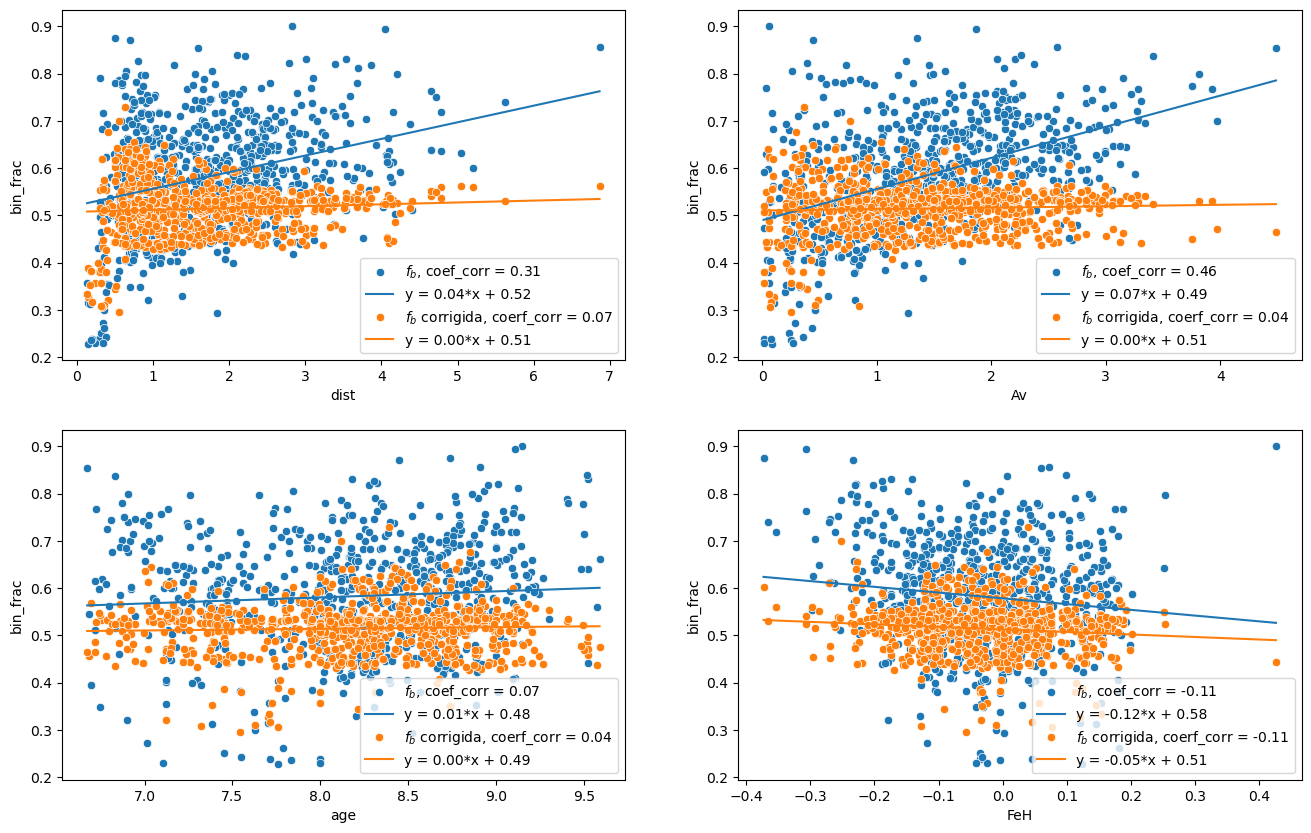

In [27]:
fig, axs = plt.subplots(2,2, figsize=(16,10))

y = 'bin_frac_corr'
xs = ['dist', 'Av', 'age', 'FeH']
i=0
j=0
for x in xs:
    #Amostra total
    coef_corr = pearsonr(df[x],df['bin_frac'])
    sns.scatterplot(data=df, x =x, y='bin_frac', ax=axs[i,j],label=fr'$f_b$, coef_corr = {coef_corr[0]:.2f}')
    model = LinearRegression()
    model.fit(df[[x]], df['bin_frac'])
    x_range = np.linspace(df[x].min(), df[x].max(), 200)
    y_pred = model.predict(x_range.reshape(-1,1)) 
    sns.lineplot(x = x_range, y = y_pred, ax = axs[i,j],label=f'y = {model.coef_[0]:.2f}*x + {model.intercept_:.2f}')
    
    coef_corr = pearsonr(df[x],df['bin_frac_corr'])
    sns.scatterplot(x = df[x], y= df['bin_frac_corr'], ax=axs[i,j],label=f'$f_b$ corrigida, coerf_corr = {coef_corr[0]:.2f}')
    model = LinearRegression()
    model.fit(df[[x]], df['bin_frac_corr'])
    x_range = np.linspace(df[x].min(), df[x].max(), 200)
    y_pred = model.predict(x_range.reshape(-1,1))
    
    sns.lineplot(x = x_range, y = y_pred, ax = axs[i,j], label=f'y = {model.coef_[0]:.2f}*x + {model.intercept_:.2f}')
    

                
    
    
    j = j+1
    if j>1:
        j=0
        i = i+1